# Minimum Feature Size Enforcement in Inverse Design of a Mode Converter

In this notebook, we apply inverse design using Tidy3D to create an integrated photonics component that converts a fundamental waveguide mode into a higher-order mode. In addition to optimizing optical performance, we explicitly enforce a minimum feature size requirement throughout the design process to ensure fabrication compatibility. This is achieved by incorporating a feature-size control procedure that integrates spatial filtering, projection, and morphology-based operators into the optimization process.

In [ ]:
from datetime import datetime
import pickle
from typing import List

import autograd.numpy as anp
import matplotlib.pylab as plt
import numpy as np

# import regular tidy3d
import tidy3d as td
import tidy3d.web as web
from autograd import value_and_grad
from tidy3d.plugins.mode import ModeSolver

# set random seed to get same results
np.random.seed(1)

# Global flag: set to True to use FlexCredits for all simulations
USE_FLEX_CREDIT = False
PAY_TYPE_KWARGS = {"pay_type": "FLEX_CREDIT"} if USE_FLEX_CREDIT else {}

# Global flag: set to True to load from a specific history file for continued optimization
OPT_CONT = False
if OPT_CONT:
    timestamp = "20240612_153000"   # Use a fixed timestamp to load a specific history file for continued optimization
else:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

history_fname = f"data/MC_{timestamp}.pkl"


In [2]:
# Parameters
# radius of the circular filter (um) and the threshold strength
radius = 0.15

# blending strategy
w_open, w_close = 0.5, 0.5

# switch tolerance
morph_tol = 0.1

# Convergence
# Learning rate
learning_rate = 0.6

# change tolerance (max |dx| between consecutive iterations)
change_tol = 0.1*learning_rate
# fabrication tolerance (difference between close and open)
fab_tol = 0.02

# Continuation staging
num_steps = 30           # Total optimization iterations
start_iter = 4           # Hold beta_min for first start_iter iterations
ramp_iter = 10           # Number of iterations to ramp beta from beta_min to beta_max

# beta parameters
beta_min = 1.0           # Smooth design (early stage)
beta_max = 10.0          # Nearly binary design (late stage)
beta_fab = beta_max

# Erosion/dilation parameters
delta_eta_fab = 0.3
eta_eroded = 1.0 - delta_eta_fab
eta_dilate = 0.0 + delta_eta_fab

## Setup

A mode source is injected into a waveguide on the left-hand side. The light propagates through a rectangular region with pixelated permittivity with the value of each pixel independently tunable between 1 (vacuum) and some maximum permittivity. Finally, we measure the transmission of the light into a waveguide on the right-hand side.

The goal of the inverse design exercise is to find the best distribution of permittivities in the coupling region to maximize the power conversion between the input mode and the output mode.

We further apply a dedicated feature-size control procedure to strictly enforce the prescribed minimum length scale, ensuring that all optimized geometric features comply with fabrication constraints while maintaining smooth device boundaries.

In [3]:
# wavelength and frequency
wavelength = 1.0
freq0 = td.C_0 / wavelength
k0 = 2 * np.pi * freq0 / td.C_0

# resolution control
min_steps_per_wvl = 16
# in the design region, we set uniform grid resolution,
# and define the design parameters on the same grid
dl_design_region = 0.01

# space between boxes and PML
buffer = 1.0 * wavelength

# optimize region size
lz = td.inf
lx = 5.0
ly = 3.0

# position of source and monitor (constant for all)
source_x = -lx / 2 - buffer * 0.8
meas_x = lx / 2 + buffer * 0.8

# total size
Lx = lx + 2 * buffer
Ly = ly + 2 * buffer
Lz = 0.0

# permittivity and width of the input/output waveguide
eps_wg = 2.75
wg_width = 0.7

# random starting parameters between 0 and 1
nx = int(lx / dl_design_region)
ny = int(ly / dl_design_region)
params0 = np.random.random((nx, ny))

# frequency width and run time
freqw = freq0 / 10
run_time = 50 / freqw

### Static Components

Next, we will set up the static parts of the geometry, the input source, and the output monitor using these parameters.

In [4]:
waveguide = td.Structure(
    geometry=td.Box(size=(2 * Lx, wg_width, lz)), medium=td.Medium(permittivity=eps_wg)
)

mode_size = (0, wg_width * 3, lz)

source_plane = td.Box(
    center=[source_x, 0, 0],
    size=mode_size,
)

measure_plane = td.Box(
    center=[meas_x, 0, 0],
    size=mode_size,
)

### Input Structures

1. Write a function to return the pixelated array given our flattened tuple of permittivity values.
2. Based on an input array of raw parameters between 0 and 1, apply a conic filter and tanh projection to compute a regularized geometric field.

In [5]:
from tidy3d.plugins.autograd import make_filter_and_project, make_erosion_dilation_penalty, rescale

filter_project = make_filter_and_project(radius, lx / nx, beta=beta_fab, eta=0.5, filter_type="conic")

def pre_process(arr, beta):
    """Apply filtering and projection with a per-iteration beta."""
    return filter_project(arr, beta=beta)

def morph(arr, eta):
    """Generic morphology using the same spatial filter, with custom eta."""
    return filter_project(arr, eta=eta)

def erode(arr):
    """Erosion pass (tighten features)."""
    return morph(arr, eta=eta_eroded)

def dilate(arr):
    """Dilation pass (expand features)."""
    return morph(arr, eta=eta_dilate)

def get_eps(params, beta, ind_morph=False):
    """Get the permittivity values (1, eps_wg) array as a function of the parameters (0, 1).
    If ind_morph is True, apply erosion-dilation closing to enforce fabrication constraints."""
    if ind_morph:
        arr_p = pre_process(params, beta=beta)
        arr_t = w_open*dilate(erode(arr_p)) + w_close*erode(dilate(arr_p))  # Close: dilate then erode
    else:
        arr_t = pre_process(params, beta=beta)
    eps = rescale(arr_t, 1, eps_wg)
    return eps

def make_input_structures(params, beta, ind_morph=False) -> List[td.Structure]:
    box = td.Box(center=(0, 0, 0), size=(lx, ly, lz))
    eps_data = get_eps(params, beta=beta, ind_morph=ind_morph).reshape((nx, ny, 1))
    custom_structure = td.Structure.from_permittivity_array(geometry=box, eps_data=eps_data)

    return [custom_structure]

### Making the Simulation
1. Write a function to return a basic `td.Simulation` as a function of parameter values.
2. Make sure to add the pixelated `td.Structure` list to `input_structures` but leave out the sources and monitors for now as they will be added after the mode solver is run.

In [6]:
def make_sim_base(params: np.ndarray, beta: float, ind_morph: bool = False) -> td.Simulation:
    """Create the simulation given the parameters and some beta value."""

    structures = make_input_structures(params, beta=beta, ind_morph=ind_morph)
    design_region_mesh = td.MeshOverrideStructure(
        geometry=td.Box(size=(lx, ly, lz)),
        dl=[dl_design_region] * 3,
        enforce=True,
    )
    grid_spec = td.GridSpec.auto(
        wavelength=wavelength,
        min_steps_per_wvl=16,
        override_structures=[design_region_mesh],
    )

    return td.Simulation(
        size=[Lx, Ly, Lz],
        grid_spec=grid_spec,
        structures=[waveguide] + structures,
        sources=[],
        monitors=[],
        run_time=run_time,
        boundary_spec=td.BoundarySpec.pml(x=True, y=True, z=False),
    )

### Visualize
Visualize the simulation to see how it looks

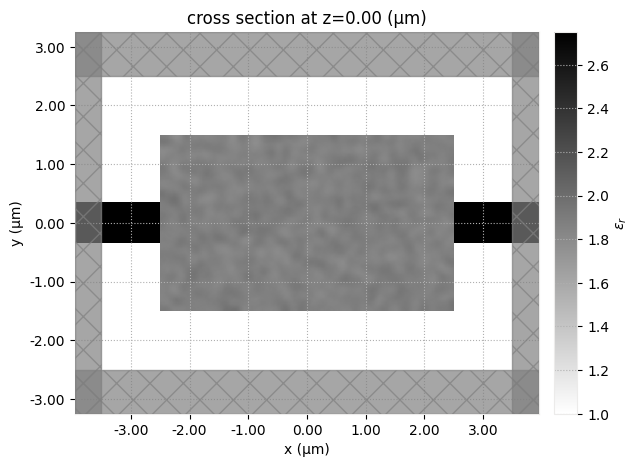

In [7]:
sim_start = make_sim_base(params0, beta=1.0)
ax = sim_start.plot_eps(z=0, freq=freq0)
plt.show()

### Select Input and Output Modes

Visualize the first 4 mode profiles so that mode indices can be selected for injection and transmition.

In [8]:
from tidy3d.plugins.mode.web import run as run_mode_solver

num_modes = 4
mode_spec = td.ModeSpec(num_modes=num_modes)

mode_solver = ModeSolver(
    simulation=sim_start,
    plane=source_plane,
    mode_spec=td.ModeSpec(num_modes=num_modes),
    freqs=[freq0],
)
modes = run_mode_solver(mode_solver, reduce_simulation=True, **PAY_TYPE_KWARGS)

15:30:05 Eastern Standard Time Mode solver created with                         
                               task_id='fdve-4579d249-aad0-4b8e-8072-0e13f80bee2
                               b',                                              
                               solver_id='mo-b903166d-b469-4454-a1fd-b843a28cdb7
                               8'.

Output()

Output()

15:30:11 Eastern Standard Time Mode solver status: success

Output()

Let's visualize the modes next.

Effective index of computed modes:  [[1.5720801  1.5354629  1.30322984 1.18481492]]


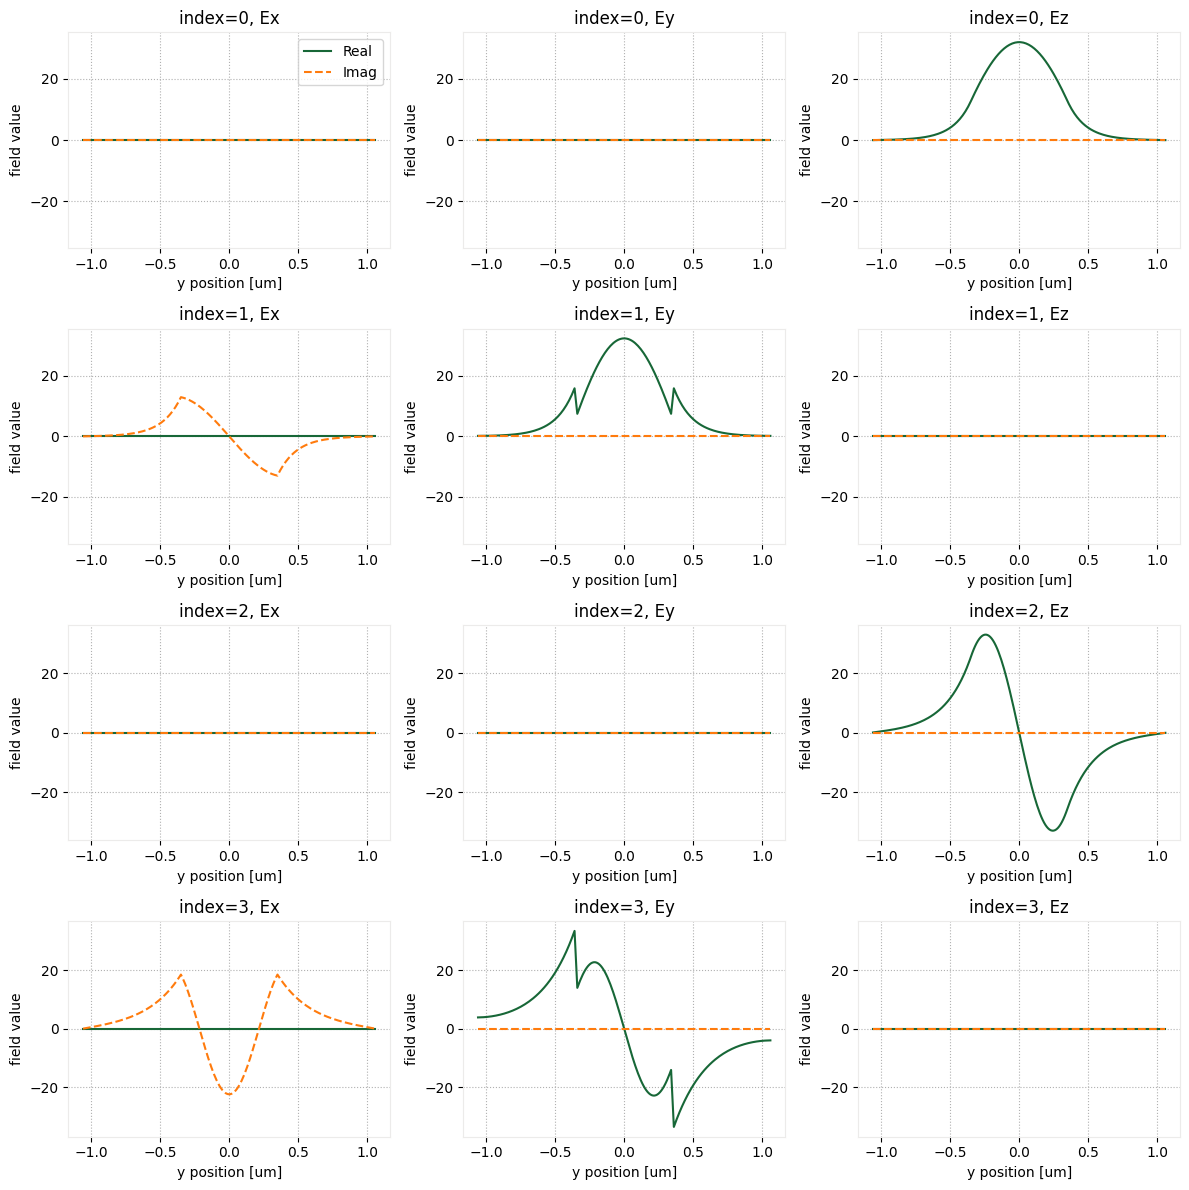

In [9]:
fig, axs = plt.subplots(num_modes, 3, figsize=(12, 12), tight_layout=True)
for mode_index in range(num_modes):
    vmax = 1.1 * max(
        abs(modes.field_components[n].sel(mode_index=mode_index)).max() for n in ("Ex", "Ey", "Ez")
    )
    for field_name, ax in zip(("Ex", "Ey", "Ez"), axs[mode_index]):
        field = modes.field_components[field_name].sel(mode_index=mode_index)
        field.real.plot(label="Real", ax=ax)
        field.imag.plot(ls="--", label="Imag", ax=ax)
        ax.set_title(f"index={mode_index}, {field_name}")
        ax.set_ylim(-vmax, vmax)

axs[0, 0].legend()

print("Effective index of computed modes: ", np.array(modes.n_eff))

1. Inject the fundamental, Ez-polarized input and convert into the 1st order Ez-polarized input.
2. From the plots, these modes correspond to the first and third rows, or `mode_index=0` and `mode_index=2`, respectively.
3. Set `mode_index_in` and `mode_index_out` variables appropriately.

In [10]:
mode_index_in = 0
mode_index_out = 2
num_modes = max(mode_index_in, mode_index_out) + 1
mode_spec = td.ModeSpec(num_modes=num_modes)

Generate source and monitor.

In [11]:
# source seeding the simulation
forward_source = td.ModeSource(
    source_time=td.GaussianPulse(freq0=freq0, fwidth=freqw),
    center=[source_x, 0, 0],
    size=mode_size,
    mode_index=mode_index_in,
    mode_spec=mode_spec,
    direction="+",
)

# we'll refer to the measurement monitor by this name often
measurement_monitor_name = "measurement"

# monitor where we compute the objective function from
measurement_monitor = td.ModeMonitor(
    center=[meas_x, 0, 0],
    size=mode_size,
    freqs=[freq0],
    mode_spec=mode_spec,
    name=measurement_monitor_name,
)

Create a new function that calls `make_sim_base()` function and adds the source and monitor to the result. This is the function in the objective function to generate `td.Simulation` given the input parameters.

In [12]:
def make_sim(params, beta, ind_morph=False):
    sim = make_sim_base(params, beta=beta, ind_morph=ind_morph)
    return sim.updated_copy(sources=[forward_source], monitors=[measurement_monitor])

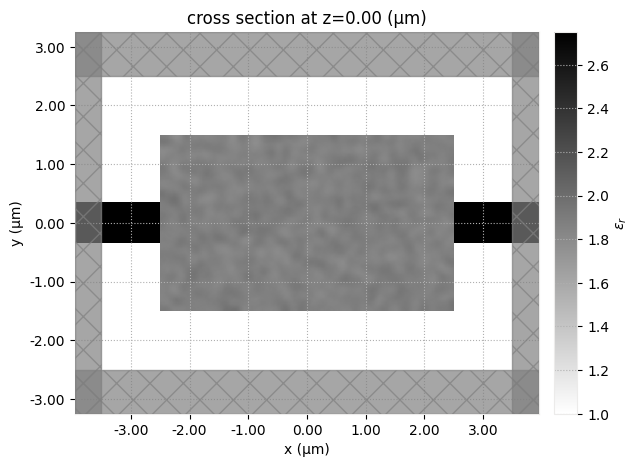

In [13]:
sim_start = make_sim_base(params0, beta=1.0)
ax = sim_start.plot_eps(z=0, freq=freq0)
plt.show()

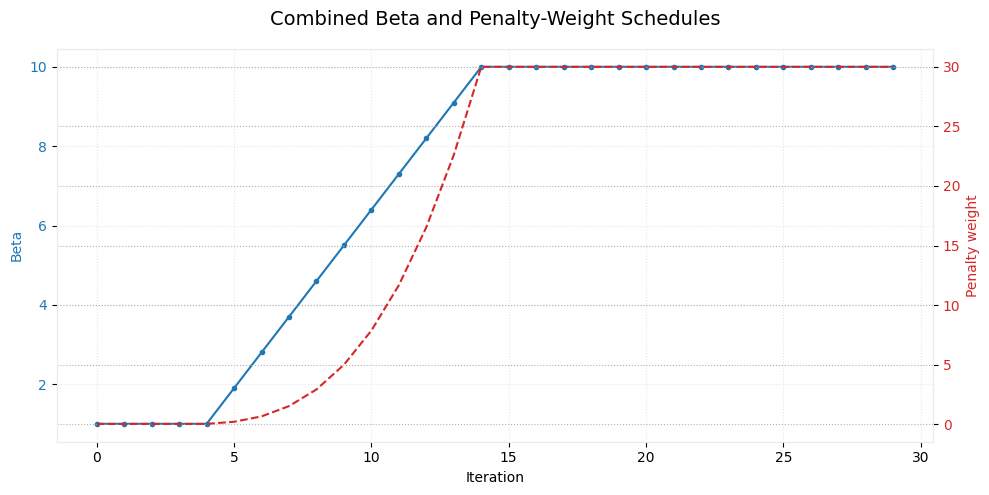

In [14]:
# Continuation Strategy (beta & penalty weight schedules)
def schedule_beta(max_iter: int,
                  start_iter: int,
                  ramp_iter: int,
                  beta_min: float,
                  beta_max: float) -> np.ndarray:
    """Compute beta schedule: hold beta_min, ramp linearly, hold beta_max."""
    steps = np.arange(max_iter)
    beta = np.empty_like(steps, dtype=float)
    ramp_end = start_iter + ramp_iter
    left = steps <= start_iter
    right = steps > ramp_end
    mid = ~(left | right)
    beta[left] = beta_min
    beta[right] = beta_max
    if mid.any():
        ramp_len = ramp_iter
        if ramp_len <= 0:
            beta[mid] = beta_max
        else:
            t = (steps[mid] - start_iter) / ramp_len
            beta[mid] = beta_min + t * (beta_max - beta_min)
    return beta

# Precompute beta schedule; penalty weight is simply (beta / beta_max)^2
beta_schedule = schedule_beta(num_steps, start_iter, ramp_iter, beta_min, beta_max)
weight_schedule = np.minimum(30.0, 30.0*(beta_schedule / beta_max) ** 3)

# Plot continuation schedules
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Beta", color="tab:blue")
ax1.plot(np.arange(num_steps), beta_schedule, color="tab:blue", marker="o", markersize=3, label="Beta Schedule")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2 = ax1.twinx()
ax2.set_ylabel("Penalty weight", color="tab:red")
ax2.plot(np.arange(num_steps), weight_schedule, color="tab:red", linestyle="--", label="Penalty Weight")
ax2.tick_params(axis="y", labelcolor="tab:red")
fig.suptitle("Combined Beta and Penalty-Weight Schedules", fontsize=14)
fig.tight_layout()
ax1.grid(True, which="both", alpha=0.3)
plt.show()

### Post Processing

Define a function to postprocess the output `td.SimulationData` object to give the conversion power to be maximized.

In [15]:
def measure_power(sim_data: td.SimulationData) -> float:
    """Return the power in the output_data amplitude at the mode index of interest."""
    output_amps = sim_data["measurement"].amps
    amp = output_amps.sel(direction="+", f=freq0, mode_index=mode_index_out).values
    return anp.sum(anp.abs(amp) ** 2)

Add a penalty to produce structures that are invariant under open and close operators.

In [16]:
erode_dilate_penalty = make_erosion_dilation_penalty(
    radius=radius,
    dl=lx / nx,
    delta_eta=delta_eta_fab,
    beta=beta_fab,
)

def compute_penalty(params, beta) -> float:
    """Compute fabrication penalty based on open and close operators."""
    arr_processed = pre_process(params, beta=beta)
    return erode_dilate_penalty(arr_processed)

### Define Objective Function

Define the objective function to be maximized as a function of input parameters (permittivity of each pixel) that returns the conversion power with an added fabrication penalty term. This is the function to be differentiated later.

In [17]:
def J(params: np.ndarray, beta: float, penalty_weight: float = 1.0,
      step_num: int = None, verbose: bool = False, ind_morph: bool = False) -> float:
    """Objective function: mode power minus weighted fabrication penalty."""
    sim = make_sim(params, beta=beta, ind_morph=ind_morph)
    task_name = "inv_des"
    if step_num:
        task_name += f"_step_{step_num}"
    sim_data = web.run(sim, task_name=task_name, verbose=verbose, **PAY_TYPE_KWARGS)
    power_val = measure_power(sim_data)
    penalty_val = compute_penalty(params, beta)
    obj_val = power_val - penalty_weight * penalty_val
    return obj_val

dJ_fn = value_and_grad(J)

### Optimization

Use "Adam" optimizer to perform sequential updates of each of the permittivity values.

For more information on what we use to implement this method, see [this article](https://optimization.cbe.cornell.edu/index.php?title=Adam).

In [ ]:
# Save history to file
def save_history(history_dict: dict) -> None:
    # Save the optimization history (e.g., objective values, parameters, penalties) to a file.
    with open(history_fname, "wb") as file:
        pickle.dump(history_dict, file)  # Serialize and save to disk

# Load history from file
def load_history() -> dict:
    # Load previously saved optimization history from file.
    with open(history_fname, "rb") as file:
        history_dict = pickle.load(file)  # Deserialize from disk
    return history_dict


Iteration = (1 / 30)


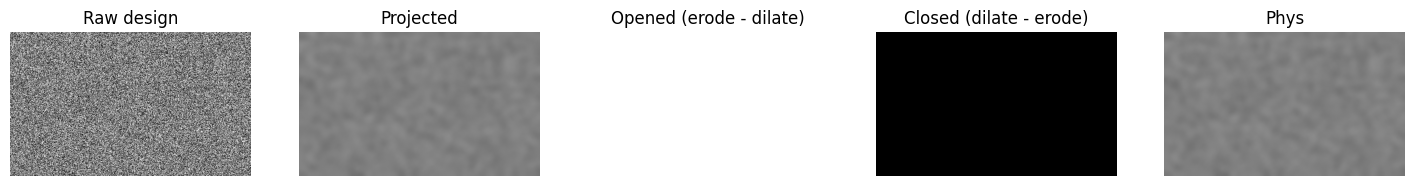

  Beta: 1.00 | Penalty weight: 0.030 | Switch: False
  Objective J: -2.9606e-02
    Power: 0.0003
    Fab penalty: 0.9978=0.9978? (tol: 0.1000)
  Gradient norm: 1.1046e-03
  Design change: 5.9955e-01 (tol: 0.06)

Iteration = (2 / 30)


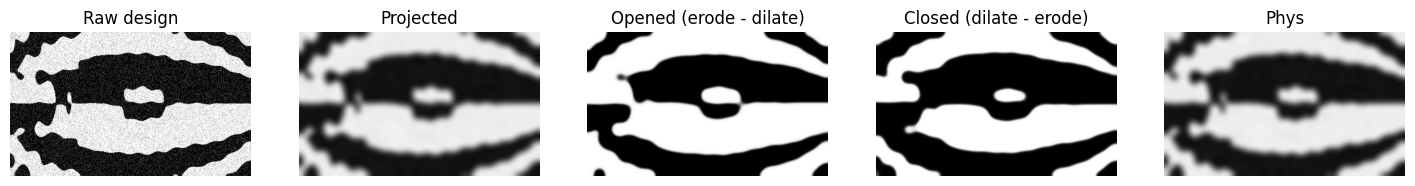

  Beta: 1.00 | Penalty weight: 0.030 | Switch: False
  Objective J: 5.8058e-02
    Power: 0.0650
    Fab penalty: 0.2308=0.2308? (tol: 0.1000)
  Gradient norm: 1.3895e-02
  Design change: 4.8635e-01 (tol: 0.06)

Iteration = (3 / 30)


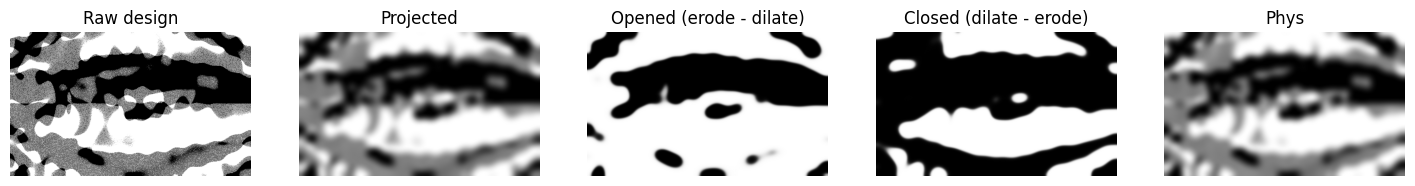

  Beta: 1.00 | Penalty weight: 0.030 | Switch: False
  Objective J: 1.9473e-01
    Power: 0.2096
    Fab penalty: 0.4972=0.4972? (tol: 0.1000)
  Gradient norm: 2.4671e-02
  Design change: 5.1557e-01 (tol: 0.06)

Iteration = (4 / 30)


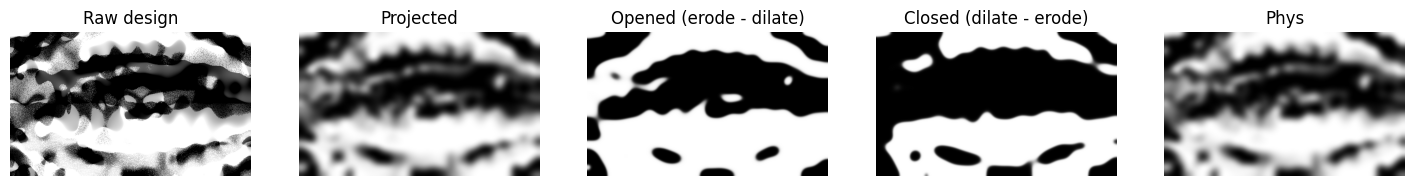

  Beta: 1.00 | Penalty weight: 0.030 | Switch: False
  Objective J: 5.5138e-03
    Power: 0.0157
    Fab penalty: 0.3410=0.3410? (tol: 0.1000)
  Gradient norm: 8.6327e-03
  Design change: 4.7335e-01 (tol: 0.06)

Iteration = (5 / 30)


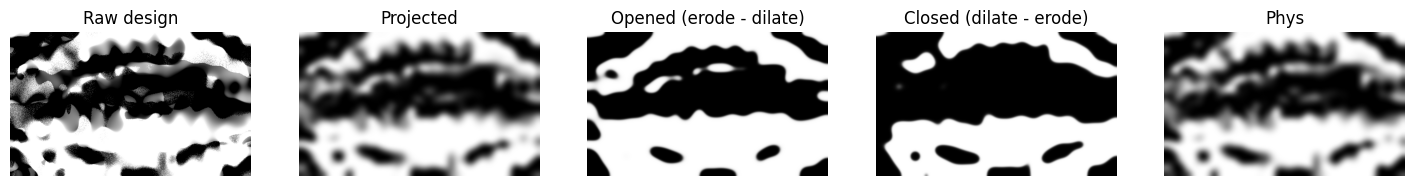

  Beta: 1.00 | Penalty weight: 0.030 | Switch: False
  Objective J: 3.6199e-01
    Power: 0.3713
    Fab penalty: 0.3090=0.3090? (tol: 0.1000)
  Gradient norm: 2.4367e-02
  Design change: 4.3688e-01 (tol: 0.06)

Iteration = (6 / 30)


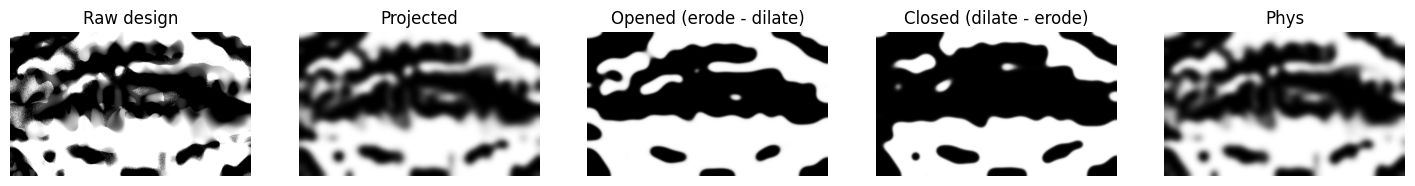

  Beta: 1.90 | Penalty weight: 0.206 | Switch: False
  Objective J: 3.0284e-01
    Power: 0.3568
    Fab penalty: 0.2622=0.2622? (tol: 0.1000)
  Gradient norm: 3.5300e-02
  Design change: 4.4254e-01 (tol: 0.06)

Iteration = (7 / 30)


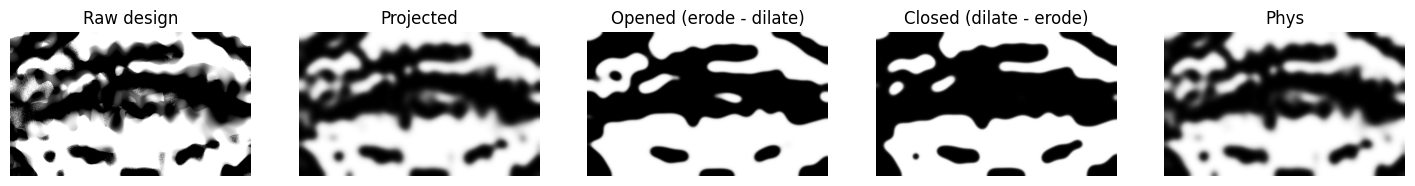

  Beta: 2.80 | Penalty weight: 0.659 | Switch: False
  Objective J: 6.2722e-01
    Power: 0.7573
    Fab penalty: 0.1976=0.1976? (tol: 0.1000)
  Gradient norm: 2.1100e-02
  Design change: 4.3506e-01 (tol: 0.06)

Iteration = (8 / 30)


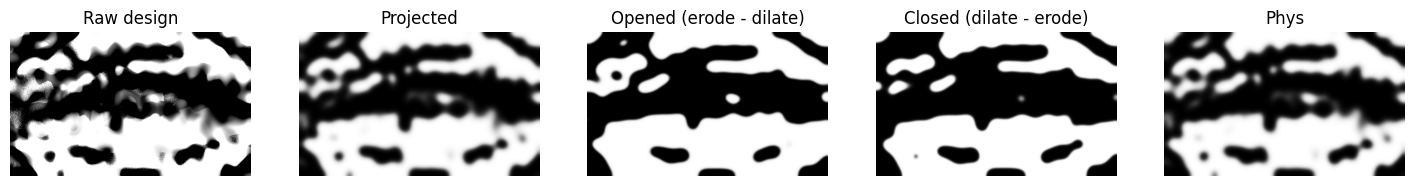

  Beta: 3.70 | Penalty weight: 1.520 | Switch: False
  Objective J: 5.8885e-01
    Power: 0.8223
    Fab penalty: 0.1537=0.1537? (tol: 0.1000)
  Gradient norm: 1.6326e-02
  Design change: 4.0875e-01 (tol: 0.06)

Iteration = (9 / 30)


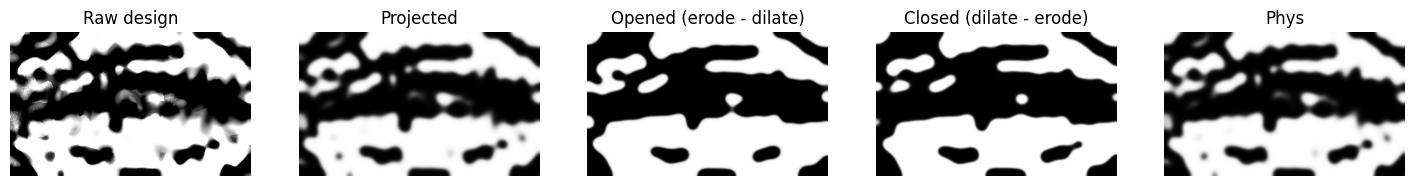

  Beta: 4.60 | Penalty weight: 2.920 | Switch: False
  Objective J: 4.9336e-01
    Power: 0.8371
    Fab penalty: 0.1177=0.1177? (tol: 0.1000)
  Gradient norm: 2.3074e-02
  Design change: 4.0423e-01 (tol: 0.06)

Iteration = (10 / 30)


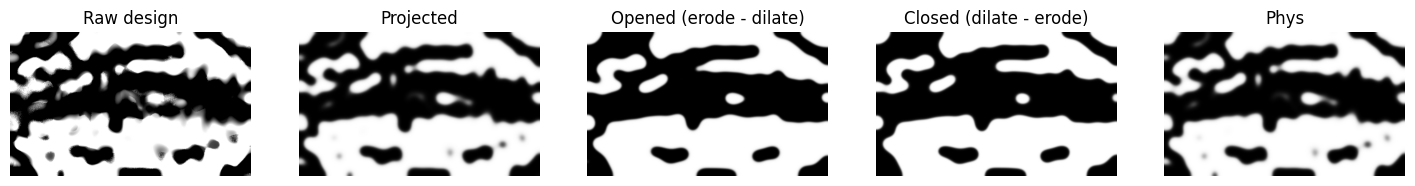

  Beta: 5.50 | Penalty weight: 4.991 | Switch: False
  Objective J: 5.2567e-01
    Power: 0.8841
    Fab penalty: 0.0718=0.0718? (tol: 0.1000)
  Gradient norm: 1.7301e-02
  Design change: 4.1009e-01 (tol: 0.06)

Iteration = (11 / 30)


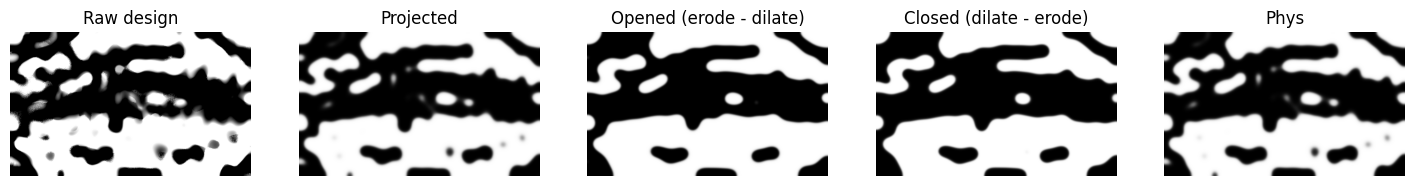

  Beta: 6.40 | Penalty weight: 7.864 | Switch: False
  Objective J: 5.2105e-01
    Power: 0.9023
    Fab penalty: 0.0485=0.0485? (tol: 0.1000)
  Gradient norm: 1.0936e-02
  Design change: 3.9824e-01 (tol: 0.06)

Iteration = (12 / 30)


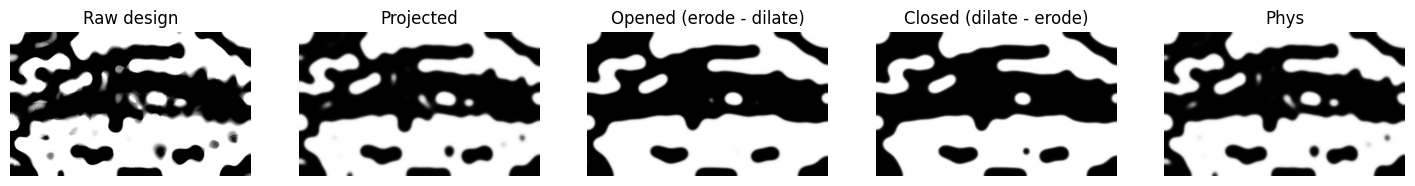

  Beta: 7.30 | Penalty weight: 11.671 | Switch: False
  Objective J: 3.7092e-01
    Power: 0.9049
    Fab penalty: 0.0458=0.0458? (tol: 0.1000)
  Gradient norm: 3.5479e-02
  Design change: 4.2616e-01 (tol: 0.06)

Iteration = (13 / 30)


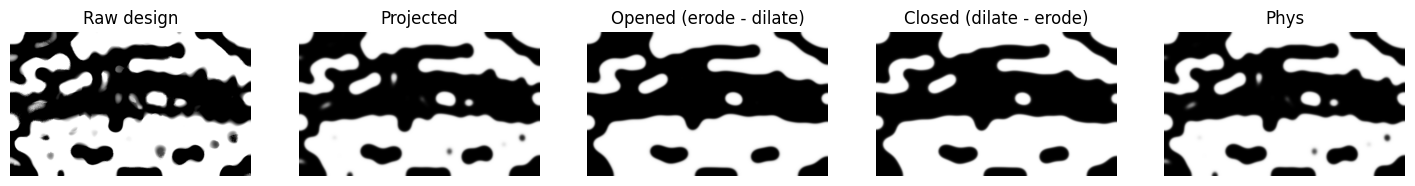

  Beta: 8.20 | Penalty weight: 16.541 | Switch: False
  Objective J: 3.9763e-01
    Power: 0.9129
    Fab penalty: 0.0312=0.0312? (tol: 0.1000)
  Gradient norm: 8.8343e-03
  Design change: 4.2380e-01 (tol: 0.06)

Iteration = (14 / 30)


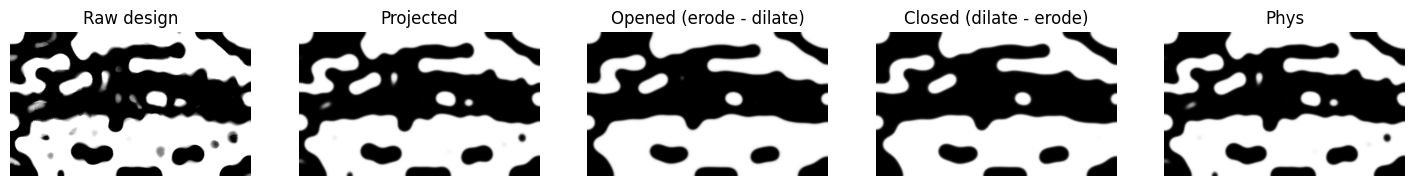

  Beta: 9.10 | Penalty weight: 22.607 | Switch: False
  Objective J: 3.1653e-01
    Power: 0.9147
    Fab penalty: 0.0265=0.0265? (tol: 0.1000)
  Gradient norm: 1.7322e-02
  Design change: 4.2819e-01 (tol: 0.06)

Iteration = (15 / 30)


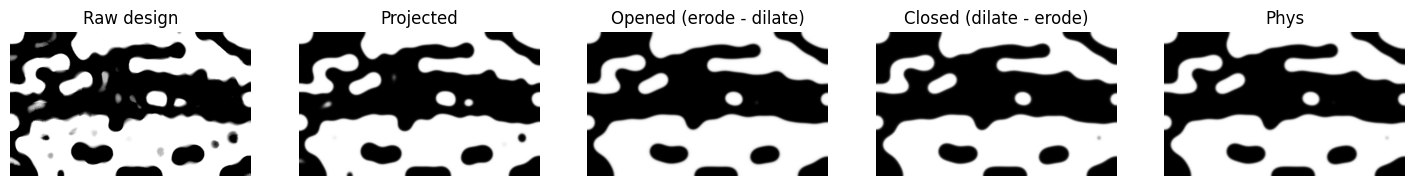

  Beta: 10.00 | Penalty weight: 30.000 | Switch: True
  Objective J: 1.6639e-01
    Power: 0.8598
    Fab penalty: 0.0231=0.0231? (tol: 0.1000)
  Gradient norm: 3.7040e-02
  Design change: 4.2508e-01 (tol: 0.06)

Iteration = (16 / 30)


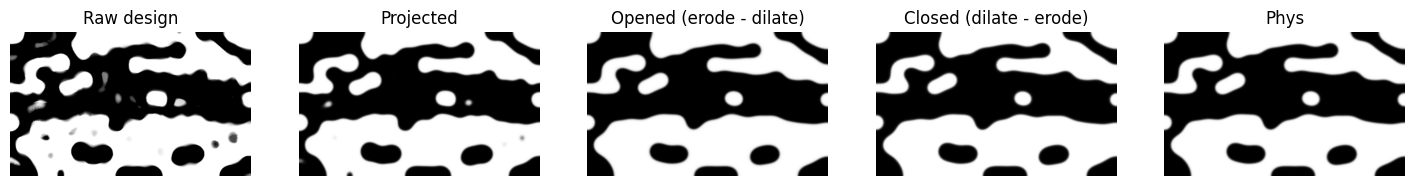

  Beta: 10.00 | Penalty weight: 30.000 | Switch: True
  Objective J: 2.5301e-01
    Power: 0.8798
    Fab penalty: 0.0209=0.0209? (tol: 0.1000)
  Gradient norm: 9.4113e-03
  Design change: 4.2932e-01 (tol: 0.06)

Iteration = (17 / 30)


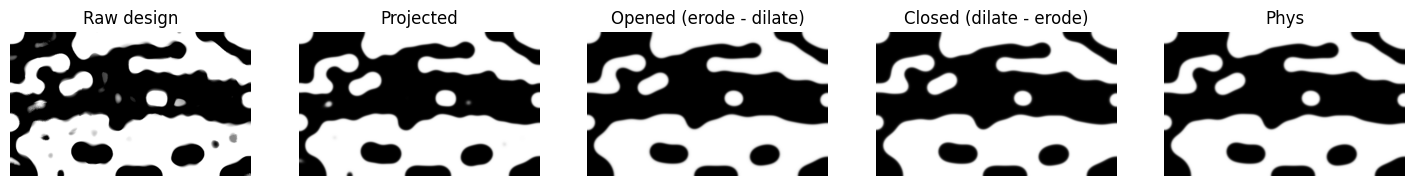

  Beta: 10.00 | Penalty weight: 30.000 | Switch: True
  Objective J: 3.0388e-01
    Power: 0.8913
    Fab penalty: 0.0196=0.0196? (tol: 0.1000)
  Gradient norm: 8.8057e-03
  Design change: 4.2663e-01 (tol: 0.06)

Iteration = (18 / 30)


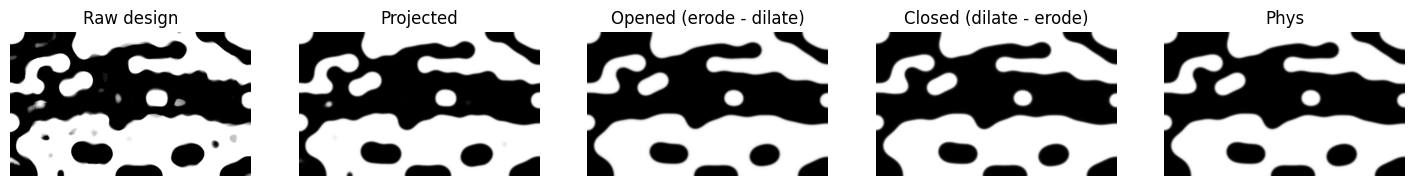

  Beta: 10.00 | Penalty weight: 30.000 | Switch: True
  Objective J: 3.3870e-01
    Power: 0.8930
    Fab penalty: 0.0185=0.0185? (tol: 0.1000)
  Gradient norm: 7.3299e-03
  Design change: 4.1258e-01 (tol: 0.06)

Iteration = (19 / 30)


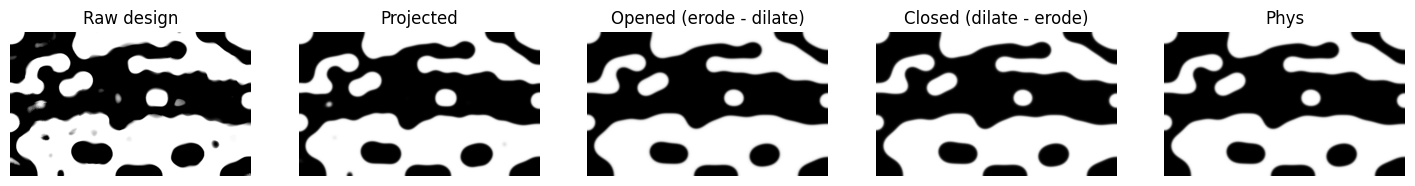

  Beta: 10.00 | Penalty weight: 30.000 | Switch: True
  Objective J: 3.6450e-01
    Power: 0.8949
    Fab penalty: 0.0177=0.0177? (tol: 0.1000)
  Gradient norm: 6.3322e-03
  Design change: 4.2497e-01 (tol: 0.06)

Iteration = (20 / 30)


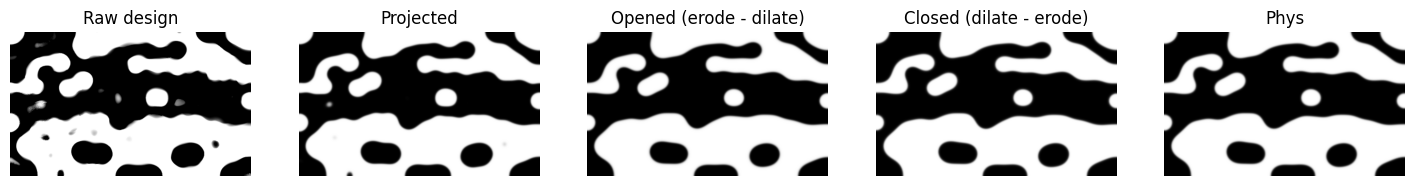

  Beta: 10.00 | Penalty weight: 30.000 | Switch: True
  Objective J: 3.8367e-01
    Power: 0.8976
    Fab penalty: 0.0171=0.0171? (tol: 0.1000)
  Gradient norm: 5.9312e-03
  Design change: 3.9512e-01 (tol: 0.06)

Iteration = (21 / 30)


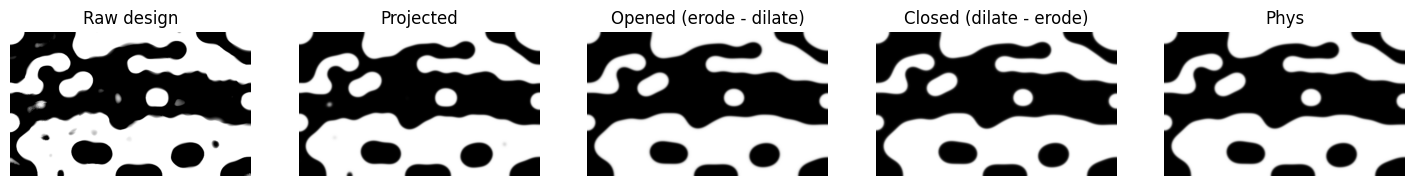

  Beta: 10.00 | Penalty weight: 30.000 | Switch: True
  Objective J: 3.9766e-01
    Power: 0.8998
    Fab penalty: 0.0167=0.0167? (tol: 0.1000)
  Gradient norm: 5.9202e-03
  Design change: 3.8892e-01 (tol: 0.06)

Iteration = (22 / 30)


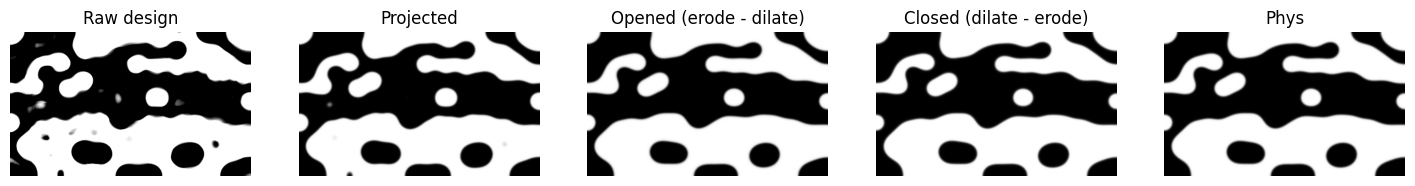

  Beta: 10.00 | Penalty weight: 30.000 | Switch: True
  Objective J: 4.0934e-01
    Power: 0.9026
    Fab penalty: 0.0164=0.0164? (tol: 0.1000)
  Gradient norm: 5.6032e-03
  Design change: 4.1050e-01 (tol: 0.06)

Iteration = (23 / 30)


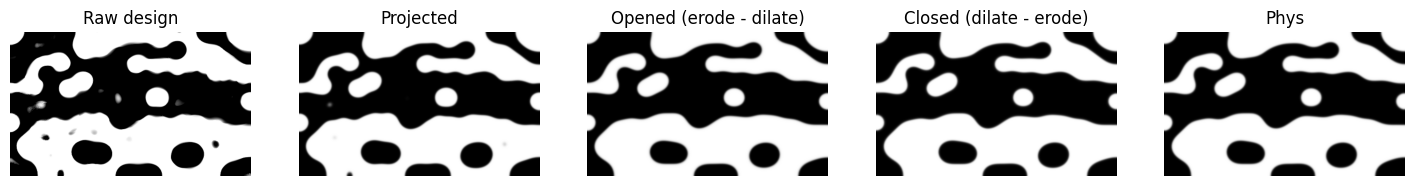

  Beta: 10.00 | Penalty weight: 30.000 | Switch: True
  Objective J: 4.1937e-01
    Power: 0.9055
    Fab penalty: 0.0162=0.0162? (tol: 0.1000)
  Gradient norm: 5.0445e-03
  Design change: 3.9185e-01 (tol: 0.06)

Iteration = (24 / 30)


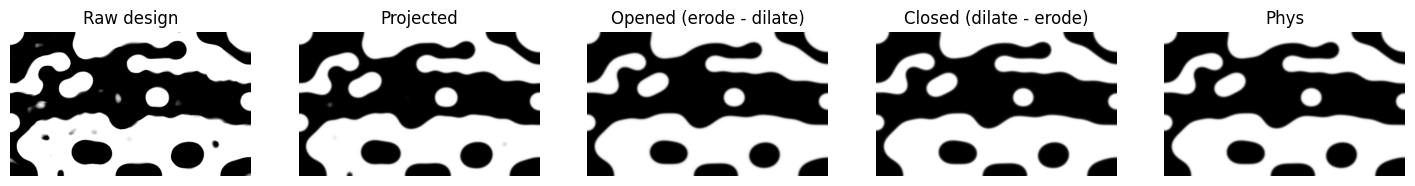

  Beta: 10.00 | Penalty weight: 30.000 | Switch: True
  Objective J: 4.2709e-01
    Power: 0.9074
    Fab penalty: 0.0160=0.0160? (tol: 0.1000)
  Gradient norm: 4.8926e-03
  Design change: 3.9286e-01 (tol: 0.06)

Iteration = (25 / 30)


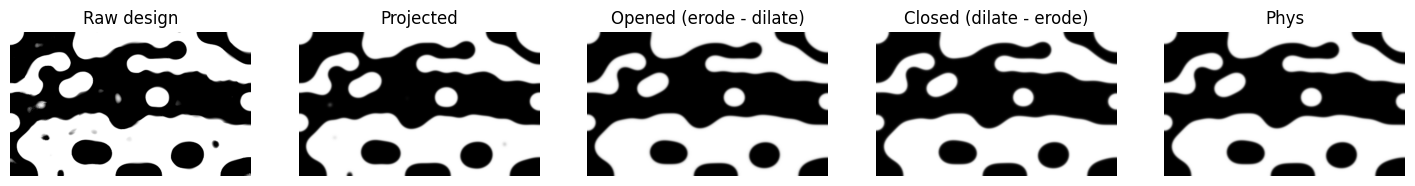

  Beta: 10.00 | Penalty weight: 30.000 | Switch: True
  Objective J: 4.3347e-01
    Power: 0.9089
    Fab penalty: 0.0158=0.0158? (tol: 0.1000)
  Gradient norm: 4.9422e-03
  Design change: 3.7628e-01 (tol: 0.06)

Iteration = (26 / 30)


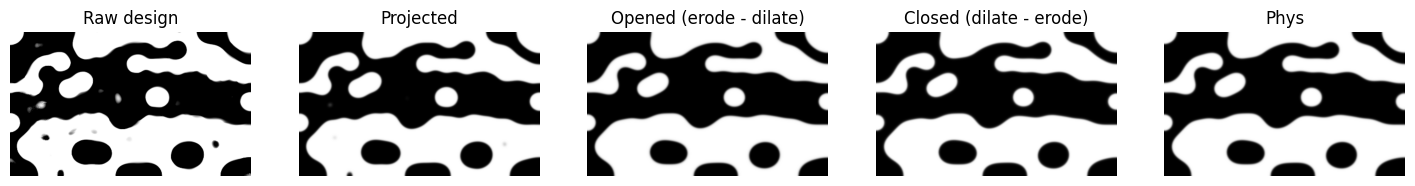

  Beta: 10.00 | Penalty weight: 30.000 | Switch: True
  Objective J: 4.3947e-01
    Power: 0.9108
    Fab penalty: 0.0157=0.0157? (tol: 0.1000)
  Gradient norm: 4.8214e-03
  Design change: 3.6303e-01 (tol: 0.06)

Iteration = (27 / 30)


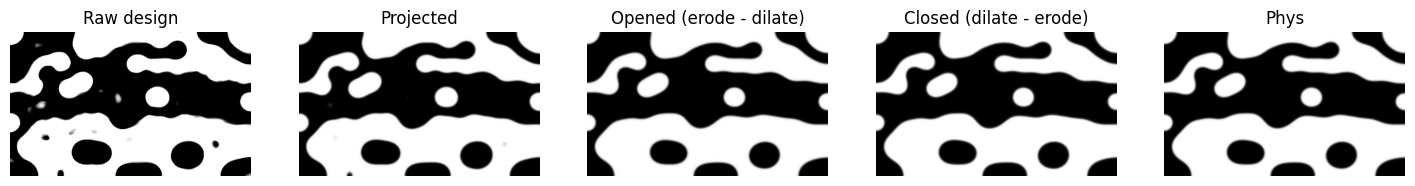

  Beta: 10.00 | Penalty weight: 30.000 | Switch: True
  Objective J: 4.4493e-01
    Power: 0.9126
    Fab penalty: 0.0156=0.0156? (tol: 0.1000)
  Gradient norm: 4.6510e-03
  Design change: 3.3911e-01 (tol: 0.06)

Iteration = (28 / 30)


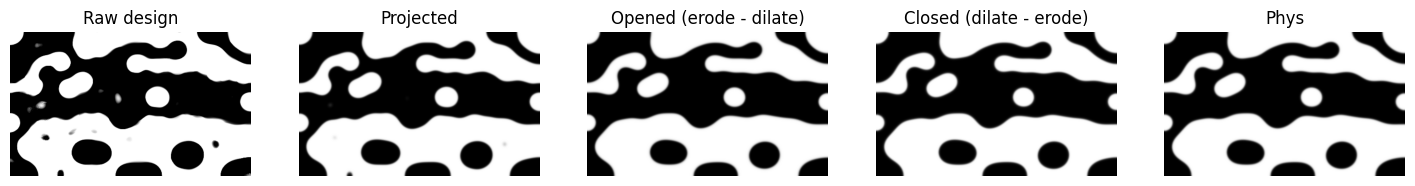

  Beta: 10.00 | Penalty weight: 30.000 | Switch: True
  Objective J: 4.4963e-01
    Power: 0.9140
    Fab penalty: 0.0155=0.0155? (tol: 0.1000)
  Gradient norm: 4.5857e-03
  Design change: 3.5204e-01 (tol: 0.06)

Iteration = (29 / 30)


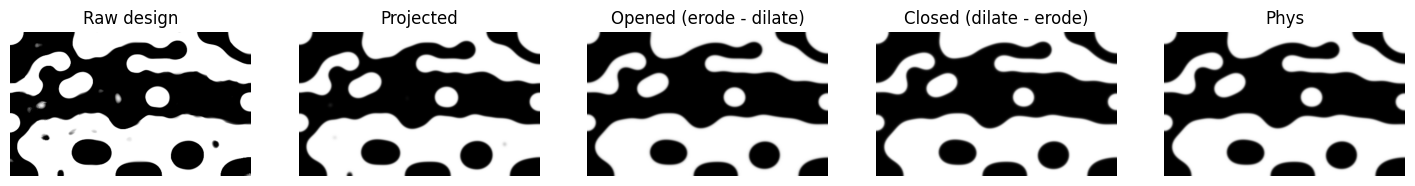

  Beta: 10.00 | Penalty weight: 30.000 | Switch: True
  Objective J: 4.5372e-01
    Power: 0.9152
    Fab penalty: 0.0154=0.0154? (tol: 0.1000)
  Gradient norm: 4.5345e-03
  Design change: 3.3704e-01 (tol: 0.06)

Iteration = (30 / 30)


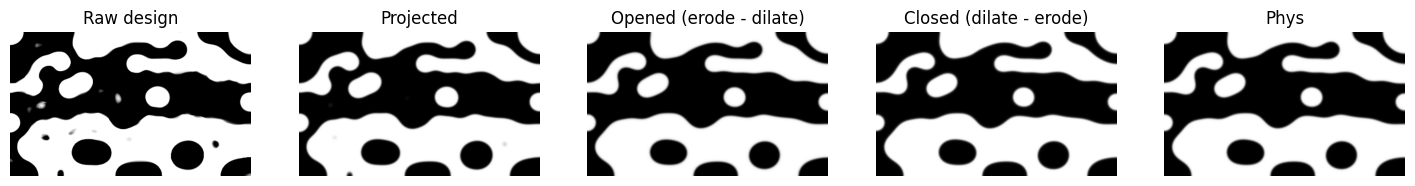

  Beta: 10.00 | Penalty weight: 30.000 | Switch: True
  Objective J: 4.5740e-01
    Power: 0.9164
    Fab penalty: 0.0153=0.0153? (tol: 0.1000)
  Gradient norm: 4.4486e-03
  Design change: 3.3699e-01 (tol: 0.06)


In [18]:
import optax

# initialize adam optimizer with starting parameters
optimizer = optax.adam(learning_rate=learning_rate)

# Attempt to load previous optimization history (checkpointing)
try:
    # Load saved history from file (if it exists)
    history = load_history()
    # Get last saved design parameters and optimizer state
    params = history["params"][-1]            # Last parameter vector
    opt_state = history["opt_states"][-1]     # Last optimizer state
    change = history["change"][-1]            # Last change value
    ind_morph_i = history["ind_morph"][-1]    # Last morphology indicator
    iter_done = len(history["params"])        # Iterations already completed
    
    # Display progress status
    print("Loaded optimization checkpoint from file.")
    print(f"Found {iter_done} iterations previously completed.")
    if iter_done < num_steps:
        print("Will resume optimization.")
    else:
        print("Optimization completed, will return results.")

# If no checkpoint found, start a new optimization run
except FileNotFoundError:
    params = anp.array(params0)         # Initialize design parameters to uniform value (e.g., 0.5 = gray)
    opt_state = optimizer.init(params)  # Initialize optimizer state
    change = 1.0                        # Initialize change to a large value to ensure the optimization loop starts
    ind_morph_i = False                 # Initialize morphology indicator to False. (Turns on when geometry is close to fabrication-ready)
    iter_done = 0                       # Initialize iterations already completed to 0
    # Initialize a fresh history dictionary to store iteration results
    history = dict(
        obj_values=[], power_values=[], penalty_values=[],
        params=[], sim_geom=[],
        gradients=[], opt_states=[opt_state], beta=[],
        change=[], ind_morph=[],
    )

if iter_done < num_steps:
    for i in range(iter_done, num_steps):
        print(f"\nIteration = ({i + 1} / {num_steps})")

        # Look up scheduled beta; penalty weight = (beta / beta_max)^2
        beta_i = beta_schedule[i]
        penalty_weight_i = weight_schedule[i]

        # --- Compute morphological views for plotting and validation ---
        params_processed_i = pre_process(params, beta=beta_i)
        opened_geom = dilate(erode(params_processed_i))     # Open: erode then dilate
        closed_geom = erode(dilate(params_processed_i))     # Close: dilate then erode
        diff_valid = closed_geom - opened_geom
        penalty_val_valid = np.linalg.norm(diff_valid) / np.sqrt(diff_valid.size)
        penalty_val_inside_J = float(compute_penalty(params, beta_i))

        # Switch to morphology-aware simulation when design is close to fabrication-ready
        # Once activated, keep it on permanently (no switching back)
        if not ind_morph_i and penalty_val_valid < morph_tol and beta_i >= beta_max - 1e-9:
            ind_morph_i = True

        # Compute objective value and gradient
        obj_val_i, gradient = dJ_fn(
            params, beta=beta_i, penalty_weight=penalty_weight_i,
            step_num=(i + 1), ind_morph=ind_morph_i
        )

        if ind_morph_i:
            phys_geom = w_open*opened_geom + w_close*closed_geom
        else:
            phys_geom = params_processed_i

        # --- Plot: Raw, Projected, Opened, Closed ---
        fig_i, axs_i = plt.subplots(1, 5, figsize=(18, 4))

        im0 = axs_i[0].imshow(1 - np.flipud(params.T), cmap="gray", vmin=0, vmax=1)
        axs_i[0].set_title("Raw design")
        axs_i[0].axis("off")

        axs_i[1].imshow(1 - np.flipud(params_processed_i.T), cmap="gray", vmin=0, vmax=1)
        axs_i[1].set_title("Projected")
        axs_i[1].axis("off")

        axs_i[2].imshow(1 - np.flipud(opened_geom.T), cmap="gray", vmin=0, vmax=1)
        axs_i[2].set_title("Opened (erode - dilate)")
        axs_i[2].axis("off")

        axs_i[3].imshow(1 - np.flipud(closed_geom.T), cmap="gray", vmin=0, vmax=1)
        axs_i[3].set_title("Closed (dilate - erode)")
        axs_i[3].axis("off")

        axs_i[4].imshow(1 - np.flipud(phys_geom.T), cmap="gray", vmin=0, vmax=1)
        axs_i[4].set_title("Phys")
        axs_i[4].axis("off")
        plt.show()

        # Apply optimizer update (negate gradient to maximize)
        params_old = params.copy()
        updates, opt_state = optimizer.update(-gradient, opt_state, params)
        params = optax.apply_updates(params, updates)

        # Clamp parameters to [0, 1]
        params = anp.minimum(params, 1.0)
        params = anp.maximum(params, 0.0)

        # Design change (max absolute difference)
        change = float(np.max(np.abs(params - params_old)))

        # Calculate power_val_i
        power_val_i = obj_val_i + penalty_weight_i * penalty_val_valid

        # --- Console output ---
        print("=" * 50)
        print(f"  Beta: {beta_i:.2f} | Penalty weight: {penalty_weight_i:.3f} | Switch: {ind_morph_i}")
        print(f"  Objective J: {obj_val_i:.4e}")
        print(f"    Power: {power_val_i:.4f}")
        print(f"    Fab penalty: {penalty_val_valid:.4f}={penalty_val_inside_J:.4f}? (tol: {morph_tol:.4f})")
        print(f"  Gradient norm: {np.linalg.norm(gradient):.4e}")
        print(f"  Design change: {change:.4e} (tol: {change_tol})")
        print("=" * 50)

        # Save history
        history["obj_values"].append(obj_val_i)
        history["power_values"].append(power_val_i)
        history["penalty_values"].append(penalty_val_valid)
        history["params"].append(params.copy())
        history["sim_geom"].append(phys_geom)
        history["beta"].append(beta_i)
        history["gradients"].append(gradient)
        history["opt_states"].append(opt_state)
        history["change"].append(change)
        history["ind_morph"].append(ind_morph_i)            
        save_history(history)

        # Early stopping: converged if 1) change is below change_tol; 2) beta has finished ramping;
        # 3) fabrication penalty is below fab_tol
        if i > 0 and change < change_tol and beta_i >= beta_max and penalty_val_valid <= fab_tol:
            print(f"  Reached early termination criteria.")
            break

In [19]:
params_final = history["params"][-1]
beta_final = history["beta"][-1]

Let's run the optimize function.

and then record the final power value (including the last iteration's parameter updates).

### Results

First, we plot the objective function (power converted to 1st order mode) as a function of step and notice that it converges nicely!

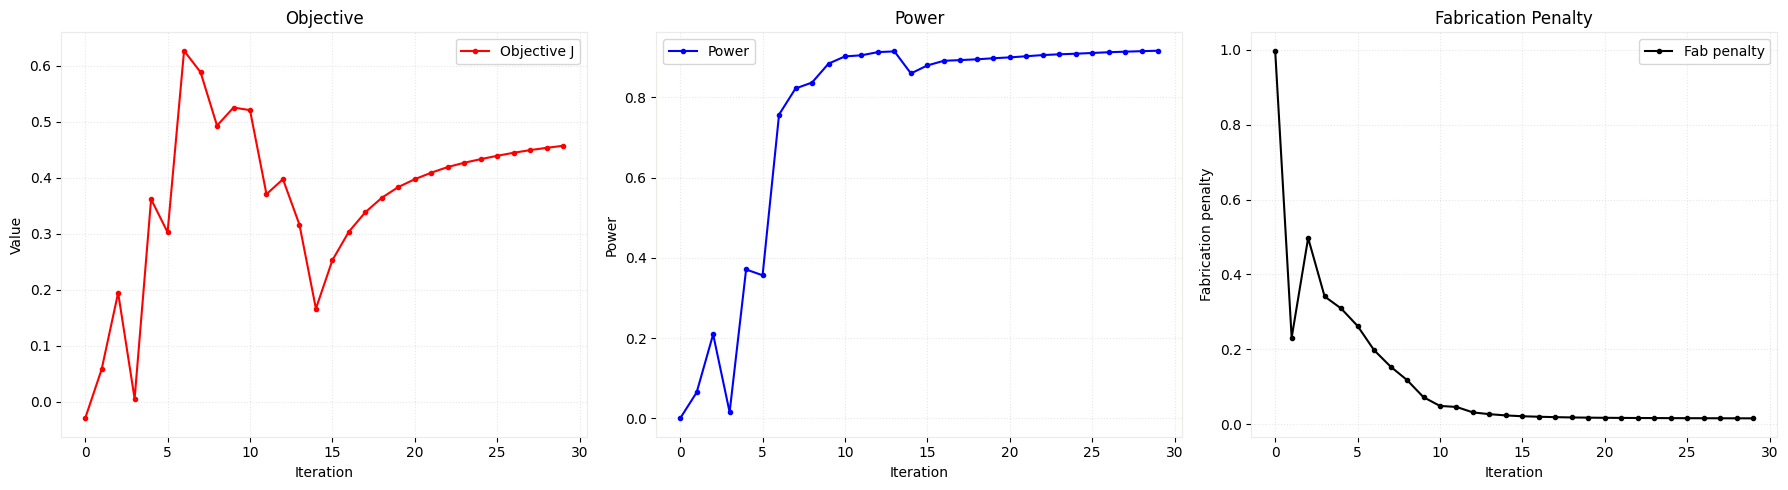

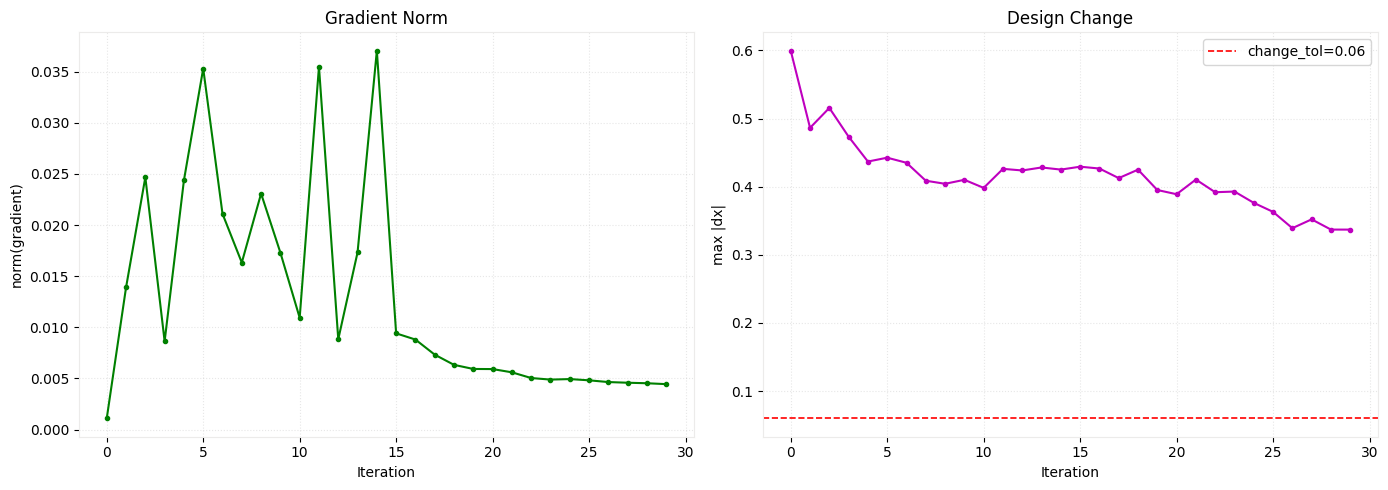

In [20]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(history["obj_values"], "r-o", label="Objective J", markersize=3)
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Value")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_title("Objective")

ax2.plot(history["power_values"], "b-o", label="Power", markersize=3)
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Power")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_title("Power")

ax3.plot(history["penalty_values"], "k-o", label="Fab penalty", markersize=3)
ax3.set_xlabel("Iteration")
ax3.set_ylabel("Fabrication penalty")
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_title("Fabrication Penalty")

plt.tight_layout()
plt.show()

# Gradient norm and design change plots
fig2, (ax4, ax5) = plt.subplots(1, 2, figsize=(14, 5))

ax4.plot([np.linalg.norm(g) for g in history["gradients"]], "g-o", markersize=3)
ax4.set_ylabel("norm(gradient)")
ax4.set_xlabel("Iteration")
ax4.grid(True, alpha=0.3)
ax4.set_title("Gradient Norm")

ax5.plot(history["change"], "m-o", markersize=3)
ax5.axhline(change_tol, color="r", linestyle="--", linewidth=1.2, label=f"change_tol={change_tol}")
ax5.set_ylabel("max |dx|")
ax5.set_xlabel("Iteration")
ax5.legend()
ax5.grid(True, alpha=0.3)
ax5.set_title("Design Change")

plt.tight_layout()
plt.show()

We then will visualize the final structure, so we convert it to a regular `Simulation` using the final permittivity values and plot it.

In [21]:
sim_final = make_sim(params_final, beta=beta_final, ind_morph=True)

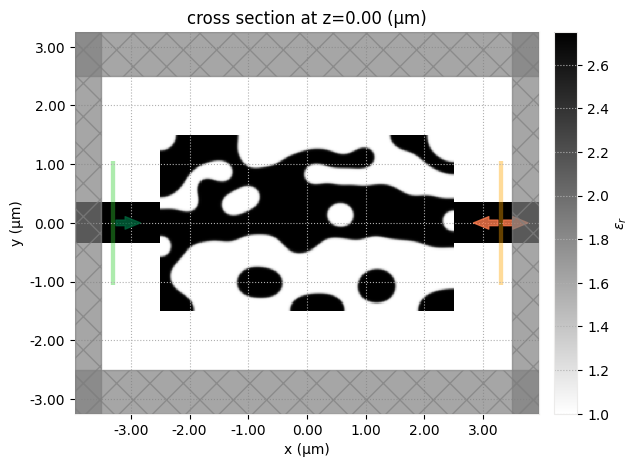

In [22]:
sim_final.plot_eps(z=0, freq=freq0)
plt.show()

Finally, we want to inspect the fields, so we add a field monitor to the `Simulation` and perform one more run to record the field values for plotting.

In [23]:
field_mnt = td.FieldMonitor(
    size=(td.inf, td.inf, 0),
    freqs=[freq0],
    name="field_mnt",
)

sim_final = sim_final.copy(update=dict(monitors=(field_mnt, measurement_monitor)))

In [24]:
sim_data_final = web.run(sim_final, task_name="inv_des_final", **PAY_TYPE_KWARGS)

16:42:10 Eastern Standard Time Created task 'inv_des_final' with task_id        
                               'fdve-76ee5618-ab32-4cfd-8f6f-df3fed09ffcb' and  
                               task_type 'FDTD'.

                               View task using web UI at                        
                               ]8;id=393603;https://tidy3d.simulation.cloud/workbench?taskId=fdve-76ee5618-ab32-4cfd-8f6f-df3fed09ffcb\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=230243;https://tidy3d.simulation.cloud/workbench?taskId=fdve-76ee5618-ab32-4cfd-8f6f-df3fed09ffcb\taskId]8;;\
                               ]8;id=393603;https://tidy3d.simulation.cloud/workbench?taskId=fdve-76ee5618-ab32-4cfd-8f6f-df3fed09ffcb\=]8;;\]8;id=849395;https://tidy3d.simulation.cloud/workbench?taskId=fdve-76ee5618-ab32-4cfd-8f6f-df3fed09ffcb\fdve]8;;\]8;id=393603;https://tidy3d.simulation.cloud/workbench?taskId=fdve-76ee5618-ab32-4cfd-8f6f-df3fed09ffcb\-76ee5618-ab32-4cfd-8f6f-df3fed09ffcb']8;;\.

                               Task folder: ]8;id=942055;https://tidy3d.simulation.cloud/folders/folder-f49e7e88-cf68-41df-b442-278c065c6d58\'default']8;;\.

Output()

16:42:13 Eastern Standard Time Maximum FlexCredit cost: 0.025. Minimum cost     
                               depends on task execution details. Use           
                               'web.real_cost(task_id)' to get the billed       
                               FlexCredit cost after a simulation run.

...

                               early shutoff detected at 12%, exiting.

                               status = success

                               View simulation result at                        
                               ]8;id=501374;https://tidy3d.simulation.cloud/workbench?taskId=fdve-76ee5618-ab32-4cfd-8f6f-df3fed09ffcb\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=946439;https://tidy3d.simulation.cloud/workbench?taskId=fdve-76ee5618-ab32-4cfd-8f6f-df3fed09ffcb\taskId]8;;\
                               ]8;id=501374;https://tidy3d.simulation.cloud/workbench?taskId=fdve-76ee5618-ab32-4cfd-8f6f-df3fed09ffcb\=]8;;\]8;id=973286;https://tidy3d.simulation.cloud/workbench?taskId=fdve-76ee5618-ab32-4cfd-8f6f-df3fed09ffcb\fdve]8;;\]8;id=501374;https://tidy3d.simulation.cloud/workbench?taskId=fdve-76ee5618-ab32-4cfd-8f6f-df3fed09ffcb\-76ee5618-ab32-4cfd-8f6f-df3fed09ffcb']8;;\.

Output()

16:43:47 Eastern Standard Time loading simulation from simulation_data.hdf5

We notice that the behavior is as expected and the device performs exactly how we intended!

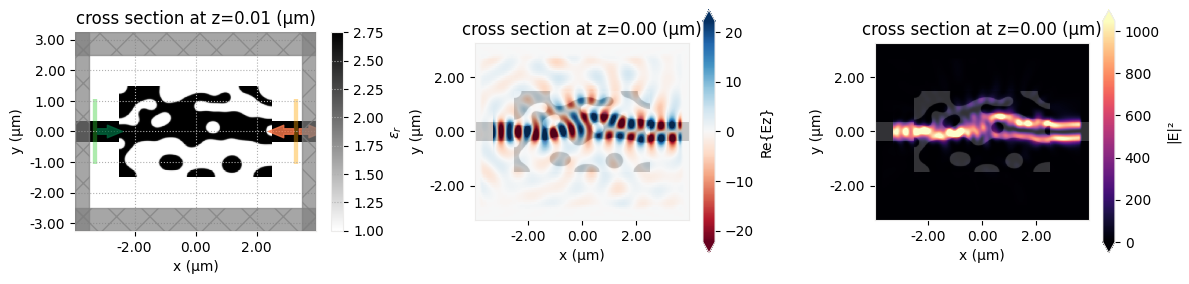

In [25]:
f, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(12, 3), tight_layout=True)
sim_final.plot_eps(z=0.01, freq=freq0, ax=ax0)
ax1 = sim_data_final.plot_field("field_mnt", "Ez", z=0, ax=ax1)
ax2 = sim_data_final.plot_field("field_mnt", "E", "abs^2", z=0, ax=ax2)

The final device converts more than 90% of the input power to the 1st mode, up from < 1% when we started.

In [26]:
final_power = (
    sim_data_final["measurement"].amps.sel(direction="+", f=freq0, mode_index=mode_index_out).abs
    ** 2
)
print(f"Final power conversion = {final_power * 100:.2f}%")

Final power conversion = 91.73%


In [29]:
sim_final.to_gds_file(
    fname=f"data/MC_{timestamp}.gds",
    z=0,
    frequency=freq0,
    permittivity_threshold=2.6,
)